# Phase 9 — Machine Learning and AI

## 9.1 Transaction Failure Prediction: Problem Definition

### Business Problem

The UPI Transaction Operational Intelligence Platform currently analyzes historical transaction failures through PostgreSQL and Power BI. However, historical reporting alone cannot warn operations teams before a transaction is processed.

The machine-learning component will investigate whether information available at transaction initiation can estimate the probability that a UPI transaction will fail.

### Prediction Question

Can the platform use transaction, merchant, banking, customer-demographic, device, network, geographical, and time-related information to predict whether a UPI transaction will succeed or fail?

### Target Variable

The model will use `transaction_status` as the target:

- `SUCCESS` → `0`
- `FAILED` → `1`

A value of `1` represents the operational event that the model must identify.

### Machine-Learning Task

This is a supervised binary-classification problem because:

1. Historical transactions contain known outcomes.
2. The target has two possible classes.
3. The model learns patterns from labelled historical data.

### Intended Business Users

- Payment operations team
- Bank-performance team
- Product management team
- Transaction-risk monitoring team
- Customer-support leadership

### Intended Business Use

The prediction probability could support:

- Early identification of high-risk transactions
- Risk-based operational monitoring
- Proactive investigation of banks, networks or transaction conditions
- Prioritisation of operational alerts
- Failure-risk reporting in Power BI

### Success Criteria

The model should:

1. Perform better than a non-informative baseline.
2. Identify a useful proportion of failed transactions.
3. Report precision, recall, F1-score and PR-AUC.
4. Produce understandable failure probabilities.
5. Avoid using information unavailable before the transaction result.
6. Provide honest conclusions if the available features have limited predictive power.

### Important Limitation

The dataset is synthetic. Earlier statistical analysis found negligible relationships between the available categorical variables and transaction status. Therefore, weak predictive performance is possible and must be reported honestly.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

pd.set_option("display.max_columns", None)

In [ ]:
# Load the processed dataset
data_path = Path("../data/processed/upi_transactions_processed.csv")

df = pd.read_csv(
    data_path,
    parse_dates=["timestamp"]
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Timestamp type: {df['timestamp'].dtype}")

df.head()

Rows: 250,000
Columns: 17
Timestamp type: datetime64[ns]


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


## 9.2 Target and Feature Selection

### Objective

The objective is to define the prediction target and select only the information that could reasonably be available when a transaction is initiated.

### Data-Leakage Prevention

Data leakage occurs when a model receives information that directly or indirectly reveals the final transaction outcome. A leaked model may produce excellent test results but fail in real operational use.

The following columns will not be used as predictors:

- `transaction_status`: this is the target itself.
- `transaction_id`: an identifier with no reusable predictive meaning.
- `fraud_flag`: potentially determined through a separate post-transaction fraud process.
- `timestamp`: the complete timestamp will be replaced with usable time components.
- `day_of_week`: duplicated by information derived from the timestamp.
- `is_weekend`: duplicated by information derived from the timestamp.
- `hour_of_day`: retained as an available operational feature.

The target is encoded as:

- `SUCCESS` = 0
- `FAILED` = 1

In [ ]:
# Validate target values
target_distribution = (
    df["transaction_status"]
    .value_counts(dropna=False)
    .rename_axis("transaction_status")
    .reset_index(name="transaction_count")
)

target_distribution["percentage"] = (
    target_distribution["transaction_count"]
    / len(df)
    * 100
).round(2)

target_distribution

,transaction_status,transaction_count,percentage
0,SUCCESS,237624,95.05
1,FAILED,12376,4.95


In [ ]:
# Create the binary target
target_mapping = {
    "SUCCESS": 0,
    "FAILED": 1
}

y = df["transaction_status"].map(target_mapping)

print("Target values:", sorted(y.dropna().unique()))
print("Missing target values:", y.isna().sum())
print("Successful transactions:", (y == 0).sum())
print("Failed transactions:", (y == 1).sum())

Target values: [np.int64(0), np.int64(1)]
Missing target values: 0
Successful transactions: 237624
Failed transactions: 12376


In [5]:
# Select predictor columns
feature_columns = [
    "transaction_type",
    "merchant_category",
    "amount_inr",
    "sender_age_group",
    "receiver_age_group",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type",
    "hour_of_day"
]

X = df[feature_columns].copy()

print(f"Selected features: {X.shape[1]}")
print(f"Feature rows: {X.shape[0]:,}")

X.head()

Selected features: 11
Feature rows: 250,000


,transaction_type,merchant_category,amount_inr,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,hour_of_day
0,P2P,Entertainment,868,26-35,18-25,Delhi,Axis,SBI,Android,4G,15
1,P2M,Grocery,1011,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,6
2,P2P,Grocery,477,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,13
3,P2P,Fuel,2784,26-35,26-35,Delhi,ICICI,PNB,Android,5G,10
4,P2P,Shopping,990,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,19


In [6]:
# Confirm excluded columns
excluded_columns = sorted(
    set(df.columns) - set(feature_columns)
)

excluded_columns

['day_of_week',
 'fraud_flag',
 'is_weekend',
 'timestamp',
 'transaction_id',
 'transaction_status']

## 9.3 Data Preparation and Train/Test Split

### Objective

The dataset will be divided into training and testing periods before preprocessing. The model will learn from earlier transactions and will be evaluated using later transactions.

### Split Strategy

A chronological 80/20 split is used instead of a random split:

- Training set: earliest 80% of transactions
- Test set: latest 20% of transactions

This approach more closely represents a production scenario in which historical data is used to predict future transaction outcomes.

### Preprocessing Strategy

- Categorical features will be converted using one-hot encoding.
- Numerical features will be standardised.
- Unknown categories appearing in future data will be safely ignored.
- Preprocessing will be fitted only on the training data to prevent leakage.

In [7]:
# Sort chronologically
model_data = df.sort_values("timestamp").reset_index(drop=True)

split_index = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_index].copy()
test_data = model_data.iloc[split_index:].copy()

print(f"Split index: {split_index:,}")
print(f"Training rows: {len(train_data):,}")
print(f"Testing rows: {len(test_data):,}")

Split index: 200,000
Training rows: 200,000
Testing rows: 50,000


In [8]:
# Create training and testing variables
X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data["transaction_status"].map(target_mapping)
y_test = test_data["transaction_status"].map(target_mapping)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (200000, 11)
X_test shape : (50000, 11)
y_train shape: (200000,)
y_test shape : (50000,)


In [9]:
# Check the time boundary
time_split_summary = pd.DataFrame({
    "dataset": ["Training", "Testing"],
    "start_timestamp": [
        train_data["timestamp"].min(),
        test_data["timestamp"].min()
    ],
    "end_timestamp": [
        train_data["timestamp"].max(),
        test_data["timestamp"].max()
    ],
    "rows": [
        len(train_data),
        len(test_data)
    ]
})

time_split_summary

,dataset,start_timestamp,end_timestamp,rows
0,Training,2024-01-01 00:05:10,2024-10-18 23:32:23,200000
1,Testing,2024-10-18 23:35:43,2024-12-30 23:55:40,50000


In [13]:
# Compare target distribution
class_distribution = pd.DataFrame({
    "dataset": ["Training", "Testing"],
    "total_transactions": [
        len(y_train),
        len(y_test)
    ],
    "failed_transactions": [
        int(y_train.sum()),
        int(y_test.sum())
    ],
    "failure_rate_percentage": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

class_distribution

,dataset,total_transactions,failed_transactions,failure_rate_percentage
0,Training,200000,9950,4.98
1,Testing,50000,2426,4.85


In [11]:
# Define feature types
categorical_features = [
    "transaction_type",
    "merchant_category",
    "sender_age_group",
    "receiver_age_group",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type"
]

numerical_features = [
    "amount_inr",
    "hour_of_day"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Categorical features: 9
Numerical features: 2
Total features: 11


In [12]:
# Create the preprocessing pipeline
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "numerical",
            numerical_transformer,
            numerical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['transaction_type', 'merchant_category',
                                  'sender_age_group', 'receiver_age_group',
                                  'sender_state', 'sender_bank',
                                  'receiver_bank', 'device_type',
                                  'network_type']),
                                ('numerical', StandardScaler(),
                                 ['amount_inr', 'hour_of_day'])])

## 9.4 Baseline Model

### Purpose

A baseline model provides a minimum performance benchmark. More advanced models should demonstrate measurable improvement over this benchmark.

The baseline uses a `DummyClassifier` with the `prior` strategy. It learns only the class distribution and does not learn relationships between transaction features and failure outcomes.

Because successful transactions represent approximately 95% of the dataset, the baseline is expected to predict every transaction as successful.

This demonstrates why accuracy alone is misleading for an imbalanced failure-prediction problem.

In [14]:
# Train the baseline
baseline_model = DummyClassifier(
    strategy="prior",
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline model trained successfully.")
print("Predicted classes:", np.unique(baseline_predictions))

Baseline model trained successfully.
Predicted classes: [0]


In [15]:
# Classification report
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=["SUCCESS", "FAILED"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     SUCCESS       0.95      1.00      0.98     47574
      FAILED       0.00      0.00      0.00      2426

    accuracy                           0.95     50000
   macro avg       0.48      0.50      0.49     50000
weighted avg       0.91      0.95      0.93     50000



In [16]:
# Confusion matrix
baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_predictions
)

baseline_confusion_matrix

array([[47574,     0],
       [ 2426,     0]])

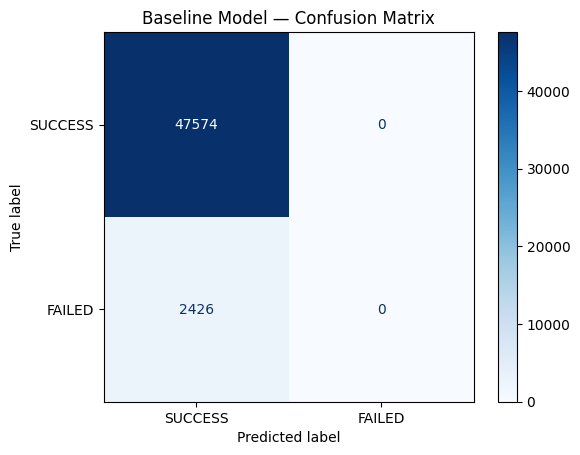

In [18]:
# Display confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=["SUCCESS", "FAILED"]
).plot(cmap="Blues")

plt.title("Baseline Model — Confusion Matrix")
plt.show()

In [17]:
# Calculate baseline metrics
baseline_metrics = pd.DataFrame({
    "model": ["Dummy Baseline"],
    "accuracy": [
        round((baseline_predictions == y_test).mean(), 4)
    ],
    "failure_precision": [
        round(
            precision_score(
                y_test,
                baseline_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "failure_recall": [
        round(
            recall_score(
                y_test,
                baseline_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "failure_f1_score": [
        round(
            f1_score(
                y_test,
                baseline_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "pr_auc": [
        round(
            average_precision_score(
                y_test,
                baseline_probabilities
            ),
            4
        )
    ],
    "roc_auc": [
        round(
            roc_auc_score(
                y_test,
                baseline_probabilities
            ),
            4
        )
    ]
})

baseline_metrics

,model,accuracy,failure_precision,failure_recall,failure_f1_score,pr_auc,roc_auc
0,Dummy Baseline,0.9515,0.0,0.0,0.0,0.0485,0.5


## 9.5 Class-Weighted Logistic Regression

### Purpose

Logistic Regression is used as the first genuine predictive model because it is efficient, interpretable, and provides transaction-failure probabilities.

### Class-Imbalance Strategy

The training dataset contains substantially fewer failed transactions than successful transactions. The model therefore uses `class_weight="balanced"` to assign greater importance to the minority failure class.

This does not create artificial records. It changes the penalty applied when the model misclassifies failed transactions.

### Evaluation Principle

The model will not be judged using accuracy alone. The primary metrics are:

- Failure precision
- Failure recall
- Failure F1-score
- Precision–Recall AUC
- ROC-AUC

In [19]:
# Build the pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'sender_age_group',
                                                   'receiver_age_group',
                                                   'sender_state',
                                                   'sender_bank',
                                                   'receiver_bank',
                                                   'device_type',
                                                   'network_type']),
                                                 ('numerical', StandardScaler(),
                                                  ['amount_inr',
                                                   'hour_of_day'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [20]:
# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [21]:
# Generate predictions
logistic_predictions = logistic_pipeline.predict(X_test)

logistic_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print(
    "Predicted successful transactions:",
    int((logistic_predictions == 0).sum())
)

print(
    "Predicted failed transactions:",
    int((logistic_predictions == 1).sum())
)

Predicted successful transactions: 26230
Predicted failed transactions: 23770


In [23]:
# Classification report
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["SUCCESS", "FAILED"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     SUCCESS       0.95      0.52      0.68     47574
      FAILED       0.05      0.47      0.09      2426

    accuracy                           0.52     50000
   macro avg       0.50      0.50      0.38     50000
weighted avg       0.91      0.52      0.65     50000



In [24]:
# Confusion Matrix
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_confusion_matrix

array([[24952, 22622],
       [ 1278,  1148]])

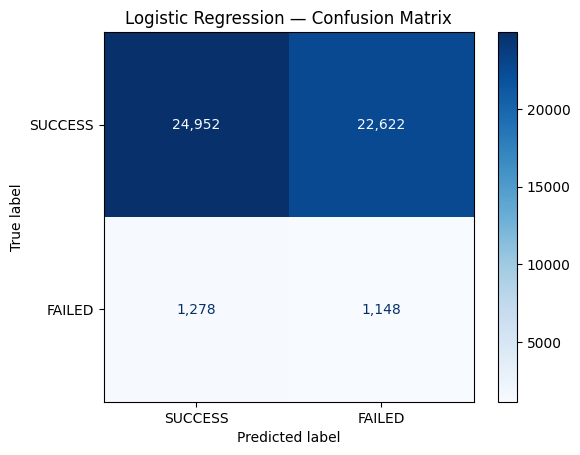

In [25]:
# Visualise the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=["SUCCESS", "FAILED"]
).plot(
    cmap="Blues",
    values_format=","
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [26]:
# Calculate model metrics
logistic_metrics = pd.DataFrame({
    "model": ["Logistic Regression"],
    "accuracy": [
        round(
            (logistic_predictions == y_test).mean(),
            4
        )
    ],
    "failure_precision": [
        round(
            precision_score(
                y_test,
                logistic_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "failure_recall": [
        round(
            recall_score(
                y_test,
                logistic_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "failure_f1_score": [
        round(
            f1_score(
                y_test,
                logistic_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "pr_auc": [
        round(
            average_precision_score(
                y_test,
                logistic_probabilities
            ),
            4
        )
    ],
    "roc_auc": [
        round(
            roc_auc_score(
                y_test,
                logistic_probabilities
            ),
            4
        )
    ]
})

logistic_metrics

,model,accuracy,failure_precision,failure_recall,failure_f1_score,pr_auc,roc_auc
0,Logistic Regression,0.522,0.0483,0.4732,0.0876,0.0478,0.495


In [27]:
# Compare with the baseline
model_comparison = pd.concat(
    [
        baseline_metrics,
        logistic_metrics
    ],
    ignore_index=True
)

model_comparison

,model,accuracy,failure_precision,failure_recall,failure_f1_score,pr_auc,roc_auc
0,Dummy Baseline,0.9515,0.0000,0.0000,0.0000,0.0485,0.500
1,Logistic Regression,0.5220,0.0483,0.4732,0.0876,0.0478,0.495


### Logistic Regression Result

The class-weighted Logistic Regression model identified 1,148 of the 2,426 failed test transactions, producing a failure recall of 47.32%.

However, the model incorrectly classified 22,622 successful transactions as failures. Failure precision was only 4.83%, meaning fewer than 5 of every 100 failure alerts were correct.

The model's PR-AUC of 0.0478 was slightly below the test-set failure prevalence of 0.0485, while its ROC-AUC of 0.495 was approximately equivalent to random ranking.

### Business Interpretation

Class weighting increased failure recall by encouraging the model to generate substantially more failure alerts. It did not reveal meaningful predictive separation between successful and failed transactions.

Deploying this model would overwhelm the operations team with false alerts and would not provide dependable transaction-level failure prediction.

### Decision

The Logistic Regression model will not be selected for deployment. A non-linear Random Forest model will be tested next to determine whether interactions between transaction attributes contain predictive information that the linear model could not identify.

## 9.6 Class-Weighted Random Forest

### Purpose

A Random Forest model is evaluated to determine whether non-linear relationships and interactions between transaction attributes can improve failure prediction.

The model uses class weighting to address the minority failure class. Tree depth and minimum leaf size are restricted to reduce overfitting and computational cost.

In [28]:
# Build the model
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=15,
                min_samples_leaf=20,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'sender_age_group',
                                                   'receiver_age_group',
                                                   'sender_state',
                                                   'sender_bank',
                                                   'receiver_bank',
                                                   'device_type',
                                                   'network_type']),
                                                 ('numerical', StandardScaler(),
                                                  ['amount_inr',
                                                   'hour_of_day'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=15, min_samples_leaf=20,
                                        n_estimators=150, n_jobs=-1,
                                        random_state=42))])

In [29]:
# Train the model
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [30]:
# Generate predictions
random_forest_predictions = random_forest_pipeline.predict(
    X_test
)

random_forest_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)

print(
    "Predicted successful transactions:",
    int((random_forest_predictions == 0).sum())
)

print(
    "Predicted failed transactions:",
    int((random_forest_predictions == 1).sum())
)

Predicted successful transactions: 47905
Predicted failed transactions: 2095


In [31]:
# Classification report
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["SUCCESS", "FAILED"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     SUCCESS       0.95      0.96      0.95     47574
      FAILED       0.04      0.04      0.04      2426

    accuracy                           0.91     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.91      0.91      0.91     50000



In [32]:
# Confusion matrix
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

random_forest_confusion_matrix

array([[45572,  2002],
       [ 2333,    93]])

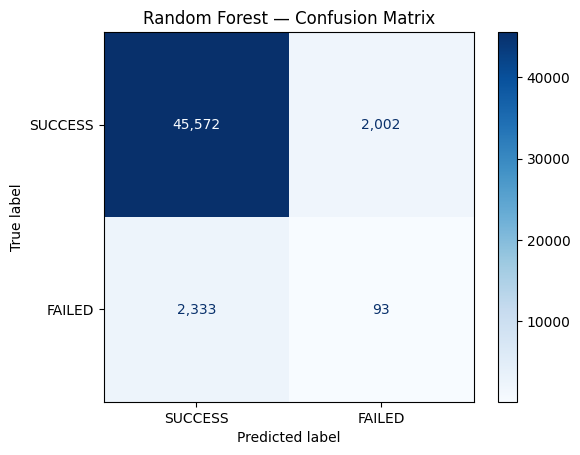

In [33]:
# Visualise confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=random_forest_confusion_matrix,
    display_labels=["SUCCESS", "FAILED"]
).plot(
    cmap="Blues",
    values_format=","
)

plt.title("Random Forest — Confusion Matrix")
plt.show()

In [34]:
# Calculate metrics
random_forest_metrics = pd.DataFrame({
    "model": ["Random Forest"],
    "accuracy": [
        round(
            (random_forest_predictions == y_test).mean(),
            4
        )
    ],
    "failure_precision": [
        round(
            precision_score(
                y_test,
                random_forest_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "failure_recall": [
        round(
            recall_score(
                y_test,
                random_forest_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "failure_f1_score": [
        round(
            f1_score(
                y_test,
                random_forest_predictions,
                zero_division=0
            ),
            4
        )
    ],
    "pr_auc": [
        round(
            average_precision_score(
                y_test,
                random_forest_probabilities
            ),
            4
        )
    ],
    "roc_auc": [
        round(
            roc_auc_score(
                y_test,
                random_forest_probabilities
            ),
            4
        )
    ]
})

random_forest_metrics

,model,accuracy,failure_precision,failure_recall,failure_f1_score,pr_auc,roc_auc
0,Random Forest,0.9133,0.0444,0.0383,0.0411,0.0483,0.5005


In [35]:
# Compare all models
model_comparison = pd.concat(
    [
        baseline_metrics,
        logistic_metrics,
        random_forest_metrics
    ],
    ignore_index=True
)

model_comparison

,model,accuracy,failure_precision,failure_recall,failure_f1_score,pr_auc,roc_auc
0,Dummy Baseline,0.9515,0.0000,0.0000,0.0000,0.0485,0.5000
1,Logistic Regression,0.5220,0.0483,0.4732,0.0876,0.0478,0.4950
2,Random Forest,0.9133,0.0444,0.0383,0.0411,0.0483,0.5005


## 9.7 Model Comparison and Deployment Decision

### Model Comparison

Three approaches were evaluated:

1. Dummy baseline
2. Class-weighted Logistic Regression
3. Class-weighted Random Forest

The Dummy baseline achieved high accuracy by predicting every transaction as successful, but it detected no failures.

Logistic Regression detected more failures, but it generated an operationally unacceptable number of false alerts.

Random Forest maintained higher overall accuracy but detected very few failures. Its ranking performance remained approximately equivalent to random selection.

### Key Finding

Neither trained model achieved PR-AUC above the test-set failure prevalence or ROC-AUC meaningfully above 0.50. This indicates that the available dataset attributes do not contain sufficient transaction-level information to distinguish successful and failed transactions reliably.

### Deployment Decision

No failure-prediction model will be deployed from the current experiment.

This is an evidence-based decision—not an unsuccessful project outcome. Deploying a statistically weak model would create misleading risk scores and unnecessary operational alerts.

### Data Improvement Requirements

A production-quality failure-prediction model would require additional pre-transaction and infrastructure attributes, such as:

- Bank response latency
- API response codes
- Payment-switch availability
- Server-load indicators
- App version
- Network latency and signal quality
- Retry count
- Bank maintenance windows
- Historical bank performance
- Recent failure rate by bank and time window
- Device operating-system version
- Detailed failure-reason codes

### Next Analytical Component

The project will proceed with unsupervised anomaly detection. This component will identify unusual transaction behaviour without claiming that anomalies are confirmed failures or fraud.

In [36]:
# Present model metrics as percentages
comparison_display = model_comparison.copy()

percentage_columns = [
    "accuracy",
    "failure_precision",
    "failure_recall",
    "failure_f1_score",
    "pr_auc",
    "roc_auc"
]

comparison_display[percentage_columns] = (
    comparison_display[percentage_columns] * 100
).round(2)

comparison_display

,model,accuracy,failure_precision,failure_recall,failure_f1_score,pr_auc,roc_auc
0,Dummy Baseline,95.15,0.00,0.00,0.00,4.85,50.00
1,Logistic Regression,52.20,4.83,47.32,8.76,4.78,49.50
2,Random Forest,91.33,4.44,3.83,4.11,4.83,50.05


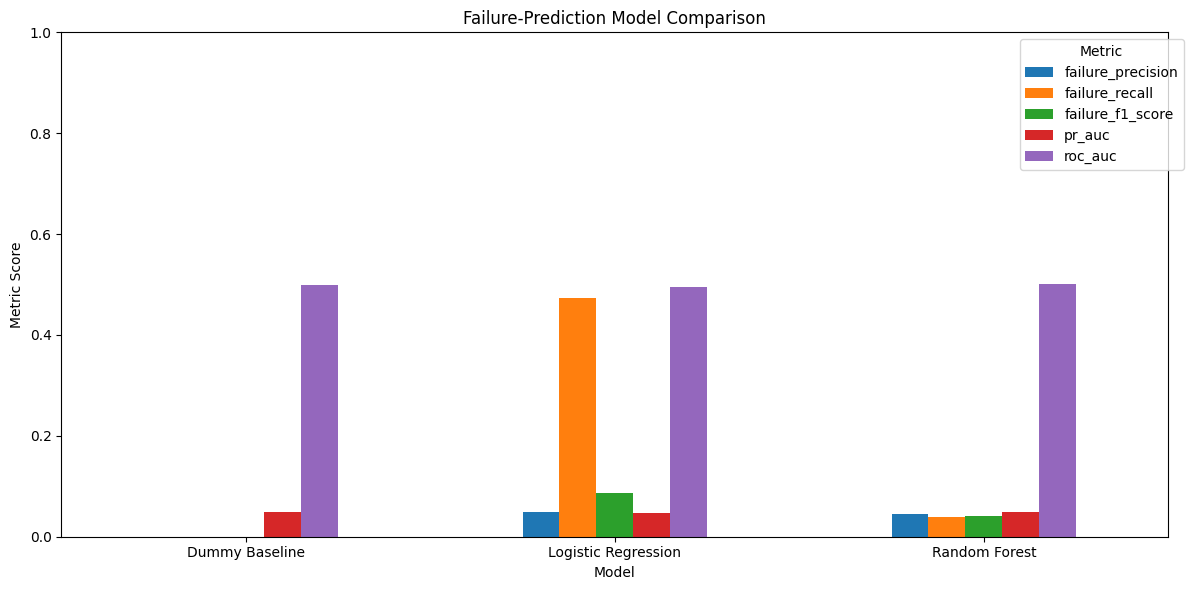

In [37]:
# Visual comparison
plot_metrics = model_comparison.set_index("model")[
    [
        "failure_precision",
        "failure_recall",
        "failure_f1_score",
        "pr_auc",
        "roc_auc"
    ]
]

plot_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Failure-Prediction Model Comparison")
plt.xlabel("Model")
plt.ylabel("Metric Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [38]:
# Record the final decision
deployment_decision = pd.DataFrame({
    "component": ["Transaction Failure Prediction"],
    "selected_model": ["None"],
    "deployment_status": ["Not recommended"],
    "reason": [
        "PR-AUC did not exceed failure prevalence and "
        "ROC-AUC remained approximately 0.50."
    ],
    "recommended_next_step": [
        "Collect infrastructure and transaction-response features."
    ]
})

deployment_decision

,component,selected_model,deployment_status,reason,recommended_next_step
0,Transaction Failure Prediction,None,Not recommended,PR-AUC did not exceed failure prevalence and R...,Collect infrastructure and transaction-respons...
